In [185]:
def findSteering ( steering, timestamps, lookback_window = 0.75, threshold=0.3):
    absteering = abs(steering) #the absolute steering deviation 
    peaks =[]
    end_times = []
    start_times = []
    durations = []
    mintime = 0 #the index of the samples I am to look in order to define a local maximum
    last_event_time = -np.inf  #the last marked peak
    for i in range(len(timestamps)-1): #the last timepoint is not important given that we are searching for motor events in a game 
        time = timestamps[i]
        if time - last_event_time < lookback_window: #non overlapping part
            continue
        while timestamps[mintime]<timestamps[i] -lookback_window:
            mintime+=1
        if absteering[i]<threshold: #we take into considaration only the true steering events
            continue
        if absteering[i]==max(absteering[mintime:i+1]) and absteering[i] > absteering[i+1]:
            true_peak = i
            while true_peak> 0 and abs(absteering[true_peak- 1] - absteering[i]) <= 0.001: #sometimes the wheel stays in the steering position continiously so this finds the first event in which the wheel reaches the peak
               true_peak -= 1
            start_time = true_peak
            #now we try to find the exact moment the steering occured
            #this code defines it as the time the steering events drift from balance, meaning the time the differences in the of the steering deviation become bigger than a given threshold
            while start_time >0: 
                diff = abs(absteering[start_time]-absteering[start_time-1]) #the difference between 2 consecutive deviation values
                peak_distance = absteering[true_peak]-absteering[start_time] # the difference between the peak deviation and the start of the steering action
                if peak_distance>0.02 and diff<0.001: #the first threshold tells the code to ignore the time before the peak as the difference between the values are close to 0 and the scond threshold defines a balance in the data
                    break
                if timestamps[start_time]<=last_event_time:
                    break
                start_time -= 1
            peaks.append(absteering[true_peak])
            end_times.append(timestamps[true_peak])
            start_times.append(timestamps[start_time])
            durations.append(timestamps[true_peak]-timestamps[start_time])
            last_event_time = time
            mintime = mintime+1
    events_df = pd.DataFrame({
        'start_time': start_times,
        'peak_time': end_times,       
        'duration': durations,
        'peak_magnitude': peaks
    })
    
    
    return events_df

In [151]:
import pickle
import numpy as np
import mne
from mne.preprocessing import ICA
import mne_icalabel
import matplotlib.pyplot as plt
import autoreject
import pandas as pd
with open("E:\\koorathota_data\\pkl_data\\pkl_data\\pkl_data\\newpkl\\Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028fixed.pkl", "rb") as f:
    data = pickle.load(f)

motor = data['Unity_MotorInput']
steering = motor[0][0]
timestamps = motor[1]




FileNotFoundError: [Errno 2] No such file or directory: 'E:\\koorathota_data\\pkl_data\\pkl_data\\pkl_data\\newpkl\\Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028fixed.pkl'

In [186]:
events_df = findSteering(steering,timestamps)
print(events_df.to_string())

      start_time    peak_time  duration  peak_magnitude
0    2385.922696  2385.922696  0.000000        0.999878
1    2439.130153  2440.159765  1.029612        0.348267
2    2441.390135  2442.600872  1.210737        0.364899
3    2460.613082  2461.840467  1.227385        0.363342
4    2462.528079  2463.540615  1.012536        0.331482
5    2562.581738  2563.528346  0.946608        0.328827
6    2570.355208  2572.082295  1.727087        0.337646
7    2573.482877  2574.230521  0.747643        0.303162
8    2591.307348  2591.614370  0.307022        0.480133
9    2592.092487  2592.591999  0.499512        0.586823
10   2600.637449  2601.185950  0.548501        0.999603
11   2620.443507  2621.350389  0.906882        0.316315
12   2631.350503  2633.109914  1.759411        0.362335
13   2642.702169  2643.360076  0.657908        0.386841
14   2647.299906  2647.648178  0.348272        0.534363
15   2649.990983  2650.661673  0.670690        0.899933
16   2654.519392  2655.434795  0.915402        0

In [200]:
import matplotlib.pyplot as plt

def plot_steering_event(steering, timestamps, events_df, event_index=101, 
                                  view_window_sec=10.0, peak_escape_drop=0.02):
    """
    Plots a steering event and highlights the 'Peak Escape Zone' to verify 
    that the algorithm is correctly ignoring the peak plateau.
    """
    if event_index >= len(events_df):
        print(f"Error: Event index {event_index} is out of bounds.")
        return
        
    # Extract event details
    event = events_df.iloc[event_index]
    start_t = event['start_time']
    peak_t = event['peak_time']
    peak_mag = event['peak_magnitude']
    
    # Define the viewing window around the event
    plot_start_t = start_t - view_window_sec
    plot_end_t = peak_t + view_window_sec
    
    # Find indices for the viewing window
    start_idx = np.searchsorted(timestamps, plot_start_t)
    end_idx = np.searchsorted(timestamps, plot_end_t)
    
    # Slice the data
    plot_timestamps = timestamps[start_idx:end_idx]
    plot_steering = np.abs(steering)[start_idx:end_idx]
    
    # Create the plot
    plt.figure(figsize=(10, 5))
    
    # Highlight the Peak Escape Zone (Yellow shaded area)
    plt.axhspan(peak_mag - peak_escape_drop, peak_mag, color='gold', alpha=0.3, 
                label=f'Escape Zone (Top {peak_escape_drop})')
    
    # Plot the steering data
    plt.plot(plot_timestamps, plot_steering, label='Absolute Steering Angle', color='royalblue', linewidth=2)
    
    # Draw Event Markers
    plt.axvline(start_t, color='green', linestyle='-', linewidth=2, label='Turn Start (Plateau Found)')
    plt.axvline(peak_t, color='red', linestyle='--', linewidth=2, label='Turn Peak')
    
    # Formatting
    plt.title(f"Steering Event {event_index} Verification")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Absolute Steering Angle")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.show()



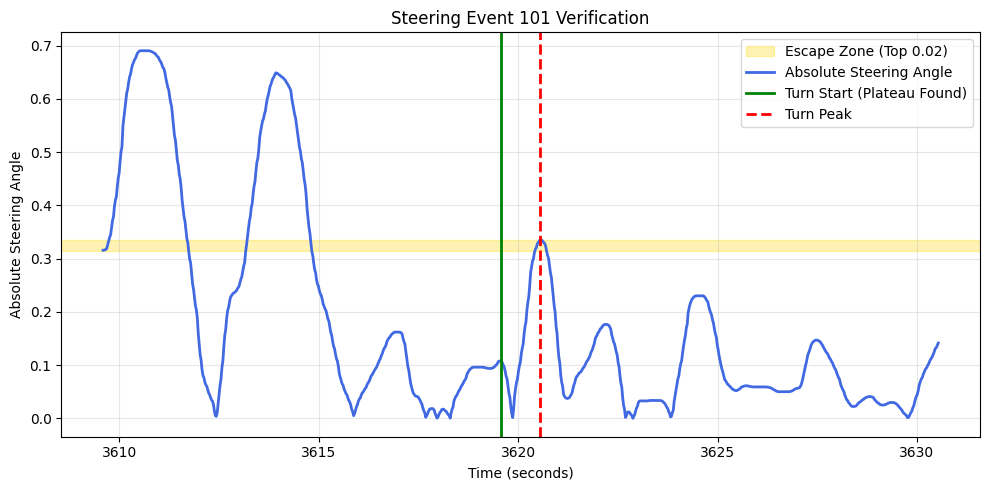

In [201]:
plot_steering_event(steering, timestamps, events_df)